In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torchvision as vision 
from torch.utils.data import DataLoader

In [33]:
class Gen(nn.Module):
    def __init__(self,z_dim=100,feat=64,out_c = 1):
        super().__init__()
        self.ff = nn.Sequential(
            nn.ConvTranspose2d(z_dim,feat*8,4,1,0,bias=False),
            nn.BatchNorm2d(feat*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(feat*8,feat*4,4,2,1,bias=False),
            nn.BatchNorm2d(feat*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(feat*4,feat*2,4,2,1,bias=False),
            nn.BatchNorm2d(feat*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(feat*2,feat,4,2,1,bias=False),
            nn.BatchNorm2d(feat),
            nn.ReLU(True),

            nn.ConvTranspose2d(feat,out_c,4,2,1,bias=False),
            nn.Tanh()
        )
        
    def forward(self,x):
        return self.ff(x)

class Disc(nn.Module):
    def __init__(self,in_c=1,feat=64):
        super().__init__()
        self.ff = nn.Sequential(
            nn.Conv2d(in_c,feat,4,2,1,bias=False),
            nn.LeakyReLU(0.2,inplace=False),

            nn.Conv2d(feat,feat*2,4,2,1,bias=False),
            nn.BatchNorm2d(feat*2),
            nn.LeakyReLU(0.2,inplace=False),

            nn.Conv2d(feat*2,feat*4,4,2,1,bias=False),
            nn.BatchNorm2d(feat*4),
            nn.LeakyReLU(0.2,inplace=False),

            nn.Conv2d(feat*4,feat*8,4,2,1,bias=False),
            nn.BatchNorm2d(feat*8),
            nn.LeakyReLU(0.2,inplace=False),

            nn.Conv2d(feat*8,1,4,2,1,bias=False)
        )
    def forward(self,x):
        return self.ff(x)

In [10]:
tfs = vision.transforms
transform = tfs.Compose([
    tfs.Resize(64),
    tfs.ToTensor(),
    tfs.Normalize((0.5,),(0.5,))
])
data = vision.datasets.MNIST("./images",train=True,download=True,transform=transform)
loader = DataLoader(data,32)

In [21]:
len(loader)

1875

In [34]:
G = Gen().cuda()
D = Disc().cuda()

optimG = torch.optim.Adam(G.parameters(),2e-4,betas=(0.5,0.999))
optimD = torch.optim.Adam(D.parameters(),2e-4,betas=(0.5,0.999))

criterion = nn.BCEWithLogitsLoss()

epochs = 5
scaler = torch.amp.GradScaler("cuda")
for epoch in range(epochs):
    G.train()
    D.train()
    print(f"Epoch {epoch+1} started")
    for bat_id , (reals,_) in enumerate(loader):
        reals = reals.cuda()
        B = reals.size(0)

        # Discriminator
        optimD.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            real_outs = D(reals) # teaching reals
            real_labels = torch.ones_like(real_outs)
            lossReal = criterion(real_outs,real_labels)

            z = torch.randn(B,100,1,1).cuda() # teaching fakes
            fake = G(z)
            fake_outs = D(fake.detach())
            fake_labels = torch.zeros_like(fake_outs)
            lossFake = criterion(fake_outs,fake_labels)

        lossD = lossFake+lossReal
        scaler.scale(lossD).backward()
        scaler.step(optimD)

        # Generator
        optimG.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            result = D(fake)
            lossG = criterion(result,real_labels)
        scaler.scale(lossG).backward()
        scaler.step(optimG)
        scaler.update()
print(f"Completed !")

Epoch 1 started
Epoch 2 started
Epoch 3 started
Epoch 4 started
Epoch 5 started
Completed !


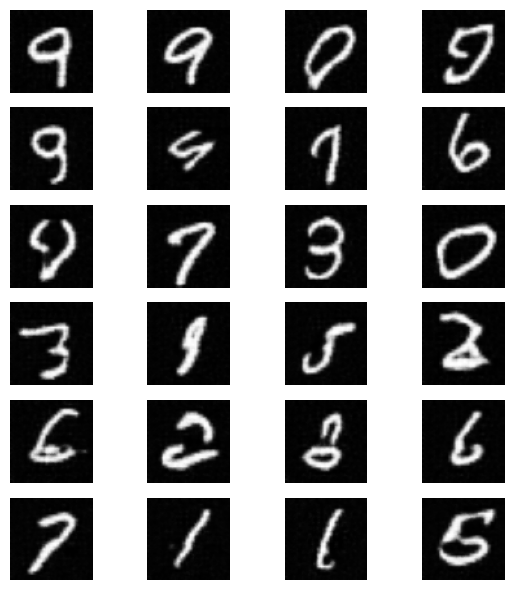

In [36]:
G.eval()

with torch.no_grad():
    z = torch.randn(24, 100, 1, 1).cuda()
    fake = G(z).cpu()

# If using Tanh, convert from [-1,1] -> [0,1]
fake = (fake + 1) / 2
fake = fake.clamp(0, 1)

fig, axes = plt.subplots(6, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(fake[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.tight_layout()